<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Output/plots/Spats/Spat_Physiology/Spat_Resp/Respiration_Rate_for_spats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Respiration_Rate for spats in ambiant

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import matplotlib.ticker as ticker

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = 'Ambient_Assay.csv'
df_resp = pd.read_csv(filename)

# Filter for the relevant morphs (just in case)
target_morphs = ['HF', 'PF', 'NF']
df_resp = df_resp[df_resp['Morph'].isin(target_morphs)]

# --- NEW: Filter samples above 2.09 and print removed samples ---
removed_ambient_samples = df_resp[df_resp['OxyRate nmol/mm2/min'] > 2.09]
if not removed_ambient_samples.empty:
    print("--- Ambient Samples Removed (OxyRate > 2.09) ---")
    for index, row in removed_ambient_samples.iterrows():
        print(f"Morph: {row['Morph']}, OxyRate: {row['OxyRate nmol/mm2/min']:.2f}")
    print("---------------------------------------------------")
df_resp = df_resp[df_resp['OxyRate nmol/mm2/min'] <= 2.09]
# ----------------------------------------------------------------

# ==========================================
# 2. STATISTICS (One-Way ANOVA)
# ==========================================
# We use ANOVA because we now have 3 groups (HF, PF, NF)
hf_vals = df_resp[df_resp['Morph'] == 'HF']['OxyRate nmol/mm2/min']
pf_vals = df_resp[df_resp['Morph'] == 'PF']['OxyRate nmol/mm2/min']
nf_vals = df_resp[df_resp['Morph'] == 'NF']['OxyRate nmol/mm2/min']

f_stat, p_val_resp = stats.f_oneway(hf_vals, pf_vals, nf_vals)
print(f"ANOVA P-value: {p_val_resp:.4f}")

# Letter assignment logic
# If p > 0.05, no difference (all 'a'). If p < 0.05, we would need post-hoc tests.
# For now, if non-significant, all get 'a'.
# if p_val_resp < 0.05:
#     # Placeholder: If significant, you might want to manually set these based on a Tukey test
#     # For now, let's assume they are different for visual distinctness if p < 0.05
#     letters_map = {'HF': 'a', 'PF': 'b', 'NF': 'c'}
# else:
#     letters_map = {'HF': 'a', 'PF': 'a', 'NF': 'a'}

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black', 'axes.linewidth': 1,
    'xtick.color': 'black', 'ytick.color': 'black',
    'text.color': 'black', 'axes.labelcolor': 'black',
    'legend.frameon': False,
    'ytick.labelsize': 11,
    'xtick.labelsize': 11
})

# Define Colors and Order
variant_colors = {'HF': '#2ca02c', 'PF': '#ff7f0e', 'NF': '#d62728'}
morph_order = ['HF', 'PF', 'NF']

plt.figure(figsize=(6, 6))

# ==========================================
# 4. PLOT CONSTRUCTION
# ==========================================

# A. Box Plot
ax = sns.boxplot(
    data=df_resp, x='Morph', y='OxyRate nmol/mm2/min', order=morph_order, palette=variant_colors,
    width=0.7, showfliers=False, linewidth=1,
    boxprops=dict(edgecolor='black', alpha=0.5),
    whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black')
)

# B. Jitter Points
sns.stripplot(
    data=df_resp, x='Morph', y='OxyRate nmol/mm2/min', order=morph_order, hue='Morph', palette=variant_colors,
    jitter=0.15, size=6, linewidth=1, edgecolor='black',
    alpha=0.7, legend=False, zorder=3
)

# C. Mean Diamond
means_resp = df_resp.groupby('Morph')['OxyRate nmol/mm2/min'].mean().reindex(morph_order)
mean_colors_resp = [variant_colors[m] for m in morph_order]
plt.scatter(range(len(morph_order)), means_resp, c=mean_colors_resp, marker='D', s=70, edgecolors='black', linewidths=2, alpha=0.9, zorder=4)

# ==========================================
# 5. ANNOTATIONS
# ==========================================
# y_offset_percent = 0.08
# max_val_global_resp = df_resp['OxyRate nmol/mm2/min'].max()

# for i, m in enumerate(morph_order):
#     subset_resp = df_resp[df_resp['Morph'] == m]['OxyRate nmol/mm2/min']
#     highest_point_resp = subset_resp.max()

#     # Add offset
#     pos_y_resp = highest_point_resp + (max_val_global_resp * y_offset_percent)

#     letter = letters_map[m]
#     plt.text(x=i, y=pos_y_resp, s=letter, ha='center', va='bottom', size=14, weight='bold')

# P-value (Bottom Right)
# p_text_resp = f"p = {p_val_resp:.3f}" if p_val_resp >= 0.0001 else "p < 0.0001"
# plt.text(0.95, -0.1, s=p_text_resp, transform=ax.transAxes,
#          ha='right', va='bottom', size=11, style='italic', color='black')

# ==========================================
# 6. LABELS & TITLE
# ==========================================
# Updated Y-label to match your CSV unit (nmol/mm2/min)
plt.ylabel("Respiration rate (nmol/mm$^2$/min)", size=13)
plt.xlabel("")
plt.title("Respiration rate of settled spats by morph \nunder ambient conditions", size=14, pad=15)

# Adjust Y limit and set ticks
plt.ylim(0, df_resp['OxyRate nmol/mm2/min'].max() * 1.25)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

sns.despine()
plt.tight_layout()

# Save
plt.savefig("Respiration_Rate_PF_Included.png", dpi=600)
plt.savefig("Respiration_Rate_PF_Included.tiff", dpi=600)
plt.savefig("Respiration_Rate_PF_Included_white.svg", dpi=600, facecolor='white')
plt.savefig("Respiration_Rate_PF_Included_transparent.svg", dpi=600, transparent=True)
plt.savefig("Respiration_Rate_PF_Included.pdf", dpi=600)

plt.show()

KeyError: 'Morph'

Respiration_Rate for spats in Light


=== Two-Way ANOVA Results ===
                           sum_sq     df         F    PR(>F)
C(morph)                 0.602021    1.0  4.201494  0.042480
C(LightDepth)            0.366050    2.0  1.277327  0.282395
C(morph):C(LightDepth)   0.245037    2.0  0.855053  0.427733
Residual                17.910928  125.0       NaN       NaN

=== Tukey's HSD Post-hoc Test Results ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
 HF_10m  HF_50m   -0.135 0.7967 -0.4407 0.1708  False
 HF_10m HF_Dark  -0.1976 0.7309 -0.6081 0.2129  False
 HF_10m  NF_10m  -0.1987 0.1823 -0.4433  0.046  False
 HF_10m  NF_50m  -0.0762  0.997 -0.5437 0.3912  False
 HF_10m NF_Dark  -0.3018 0.3458 -0.7376  0.134  False
 HF_50m HF_Dark  -0.0627 0.9989 -0.5371 0.4118  False
 HF_50m  NF_10m  -0.0637 0.9944 -0.4049 0.2775  False
 HF_50m  NF_50m   0.0587 0.9995 -0.4658 0.5832  False
 HF_50m NF_Dark  -0.1668 0.9

/tmp/ipython-input-3427189452.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby(x_col)["OxyRate"].mean().reindex(x_order)
/tmp/ipython-input-3427189452.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby(x_col)["OxyRate"].mean().reindex(x_order)
/tmp/ipython-input-3427189452.py:154: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)


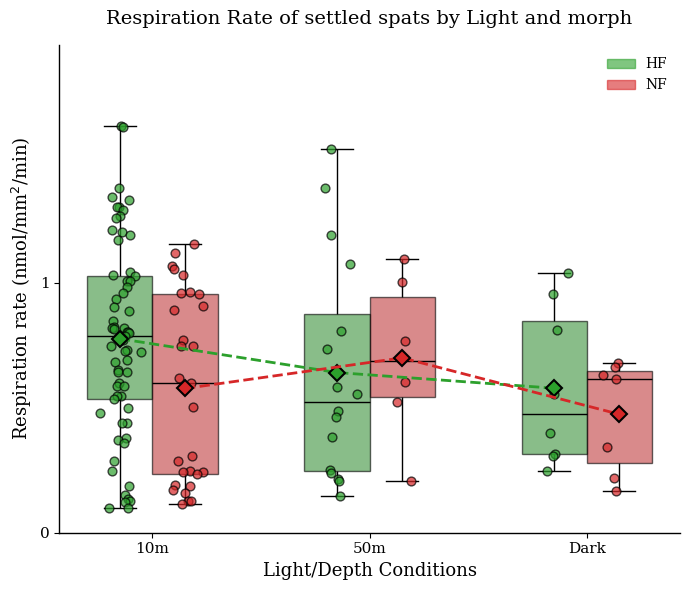

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Light_Spat_Resp.csv"
df = pd.read_csv(filename)

# --- Handle 'morph' and 'color' columns consistently ---
# The prompt states 'color' contains HF/NF info, so we use that as the canonical 'morph' column.
if 'color' in df.columns:
    # Save the desired 'morph' data from 'color' before dropping anything
    desired_morph_data = df['color'].copy()
    # Drop the original 'color' column
    df = df.drop(columns=['color'])
    # If an old 'morph' column exists, drop it to prevent duplicates
    if 'morph' in df.columns:
        df = df.drop(columns=['morph'])
    # Add the desired 'morph' data as the canonical 'morph' column
    df['morph'] = desired_morph_data
# else: If 'color' column doesn't exist, assume 'morph' column is already correctly named and contains HF/NF.

# Rename 'OxyRate nmol/mm2/min' to 'OxyRate'
df = df.rename(columns={
    "OxyRate nmol/mm2/min": "OxyRate"
})

# --- NEW: Filter samples above 2.09 and print removed samples ---
removed_light_samples = df[df['OxyRate'] > 2.09]
if not removed_light_samples.empty:
    print("--- Light Samples Removed (OxyRate > 2.09) ---")
    for index, row in removed_light_samples.iterrows():
        print(f"Morph: {row['morph']}, OxyRate: {row['OxyRate']:.2f}")
    print("--------------------------------------------------")
df = df[df['OxyRate'] <= 2.09]
# ----------------------------------------------------------------

# Clean and Order the LightDepth column
# Logic: High Light (10m) -> Low Light (50m) -> No Light (Dark)
df["LightDepth"] = df["LightDepth"].astype(str).str.strip()
light_order = ["10m", "50m", "Dark"]
df["LightDepth"] = pd.Categorical(df["LightDepth"], categories=light_order, ordered=True)

# Drop rows with unexpected LightDepth values
df = df[df["LightDepth"].isin(light_order)].copy()
df = df.reset_index(drop=True) # Ensure unique index after filtering

# ==========================================
# 2. STATISTICS (Two-Way ANOVA & Tukey's HSD)
# ==========================================
# Model: OxyRate depends on morph and LightDepth
model = ols("OxyRate ~ C(morph) + C(LightDepth) + C(morph):C(LightDepth)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA Results ===")
print(anova_table)

# 2.1 Tukey's HSD Post-hoc Test
df['group'] = df['morph'].astype(str) + "_" + df['LightDepth'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df['OxyRate'], groups=df['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result)

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

# ==========================================
# 4. PLOT CONSTRUCTION
# ==========================================
box_width = 0.6
offset = box_width / 4

x_positions = {
    "HF": -offset,
    "NF": +offset
}

# Variable to plot on X-axis
x_col = "LightDepth"
x_order = light_order

for morph in morph_order:
    sub = df[df["morph"] == morph]

    # A. Boxplots
    sns.boxplot(
        data=sub, x=x_col, y="OxyRate",
        order=x_order,
        width=box_width / 2,
        color=variant_colors[morph],
        showfliers=False, linewidth=1,
        boxprops=dict(edgecolor="black", alpha=0.6),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        ax=ax,
        positions=np.arange(len(x_order)) + x_positions[morph]
    )

    # B. Jittered points
    for i, level in enumerate(x_order):
        y = sub[sub[x_col] == level]["OxyRate"]
        # Add random jitter to x
        x = np.random.normal(i + x_positions[morph], 0.04, size=len(y))

        ax.scatter(
            x, y,
            s=40, c=variant_colors[morph],
            edgecolors="black", linewidths=1,
            alpha=0.7, zorder=3
        )

    # C. Mean diamonds (changed from median)
    means = sub.groupby(x_col)["OxyRate"].mean().reindex(x_order)

    ax.plot(
        np.arange(len(x_order)) + x_positions[morph],
        means,
        marker="D", linestyle="--",
        markersize=8,
        markerfacecolor=variant_colors[morph],
        markeredgecolor="black",
        markeredgewidth=1.5,
        linewidth=2,
        color=variant_colors[morph],
        zorder=4
    )

# ==========================================
# 5. LABELS, LEGEND & ANNOTATION
# ==========================================
ax.set_ylabel("Respiration rate (nmol/mm$^2$/min)", fontsize=13)
ax.set_xlabel("Light/Depth Conditions", fontsize=13)
ax.set_title("Respiration Rate of settled spats by Light and morph", fontsize=14, pad=15)

# Custom Legend
legend_handles = []
for morph in morph_order:
    patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
    legend_handles.append(patch)
ax.legend(handles=legend_handles, labels=morph_order, title=None, frameon=False, loc="upper right")

# Fix X-axis ticks
ax.set_xticks(np.arange(len(x_order)))
ax.set_xticklabels(x_order)

# Y-axis formatting
max_val = df["OxyRate"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1)) # Adjusted tick frequency to 1

sns.despine(ax=ax)
fig.tight_layout()

# Save options
plt.savefig("Respiration_Rate_by_Light.png", dpi=600)
plt.savefig("Respiration_Rate_by_Light.pdf", dpi=600)
plt.savefig("Respiration_Rate_by_Light.tiff", dpi=600)
plt.savefig("Respiration_Rate_by_Light_transparent.svg", dpi=600, transparent=True)
plt.savefig("Respiration_Rate_by_Light_white.svg", dpi=600, facecolor='white')
plt.show()

Respiration_Rate for spats in Temp

=== Two-Way ANOVA Results ===
                     sum_sq     df          F        PR(>F)
C(morph)           0.339313    1.0   2.480124  1.173321e-01
C(temp)            4.977184    2.0  18.189758  8.013258e-08
C(morph):C(temp)   0.401670    2.0   1.467956  2.335811e-01
Residual          21.205985  155.0        NaN           NaN

=== Tukey HSD ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 HF_23  HF_27  -0.4904    0.0 -0.7628  -0.218   True
 HF_23  HF_32  -0.4323 0.0694 -0.8841  0.0195  False
 HF_23  NF_23  -0.1589 0.2528 -0.3692  0.0514  False
 HF_23  NF_27  -0.4619 0.0001 -0.7542 -0.1696   True
 HF_23  NF_32  -0.1965 0.9763 -0.9606  0.5676  False
 HF_27  HF_32   0.0582 0.9994 -0.4417   0.558  False
 HF_27  NF_23   0.3315 0.0209  0.0316  0.6314   True
 HF_27  NF_27   0.0285 0.9999 -0.3337  0.3907  False
 HF_27  NF_32   0.2939 0.8929 -0.4995  1.0874  False
 HF_32  NF_23  

/tmp/ipython-input-22248346.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("temp")["OxyRate"].mean().reindex(temp_order)
/tmp/ipython-input-22248346.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("temp")["OxyRate"].mean().reindex(temp_order)
/tmp/ipython-input-22248346.py:148: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)


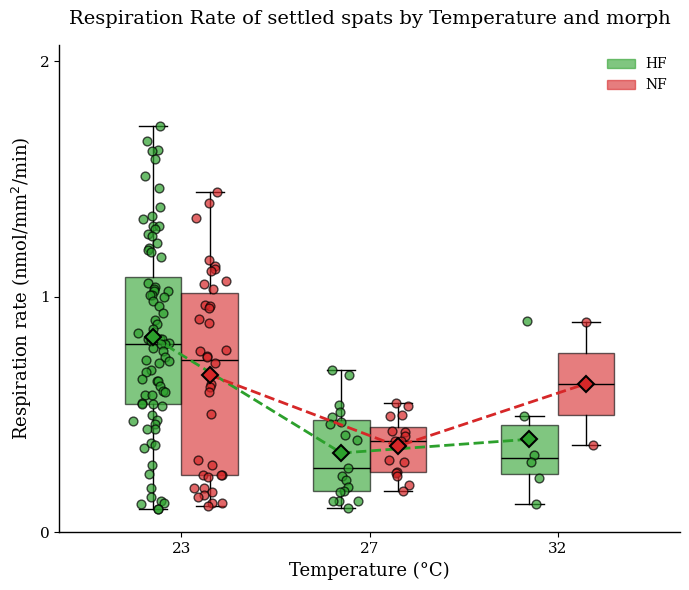

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Temp_Spat_Resp.csv"
df = pd.read_csv(filename)

# Clean column names
df = df.rename(columns={"OxyRate nmol/mm2/min": "OxyRate"})
if 'color' in df.columns:
    df = df.rename(columns={"color": "morph"})

# --- DATA CLEANING ---
# 1. Filter Outliers (0.1 - 2.09)
removed_temp_samples = df[(df['OxyRate'] < 0.1) | (df['OxyRate'] > 2.09)]
if not removed_temp_samples.empty:
    print("--- Temperature Samples Removed (OxyRate < 0.1 or > 2.09) ---")
    for index, row in removed_temp_samples.iterrows():
        print(f"Morph: {row['morph']}, OxyRate: {row['OxyRate']:.2f}")
    print("-----------------------------------------------------------")
df = df[(df['OxyRate'] >= 0.1) & (df['OxyRate'] <= 2.09)]

# 2. Reset Index
df = df.reset_index(drop=True)

# 3. Ensure Temp is Ordered Categorical
temp_order = [23, 27, 32]
df["temp"] = pd.Categorical(df["temp"], categories=temp_order, ordered=True)

# ==========================================
# 2. STATISTICS (Two-Way ANOVA)
# ==========================================
model = ols("OxyRate ~ C(morph) + C(temp) + C(morph):C(temp)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA Results ===")
print(anova_table)

# Post-hoc Test
df['group'] = df['morph'].astype(str) + "_" + df['temp'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df['OxyRate'], groups=df['group'], alpha=0.05)
print("\n=== Tukey HSD ===")
print(tukey_result)

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

# ==========================================
# 4. PLOT CONSTRUCTION (MANUAL ALIGNMENT)
# ==========================================
box_width = 0.6
offset = box_width / 4

x_positions = {
    "HF": -offset,
    "NF": +offset
}

for morph in morph_order:
    sub = df[df["morph"] == morph]

    # Prepare data for manual boxplot (list of arrays)
    plot_data = [sub[sub["temp"] == t]["OxyRate"].values for t in temp_order]

    positions = np.arange(len(temp_order)) + x_positions[morph]

    # A. Boxplots
    bp = ax.boxplot(
        plot_data,
        positions=positions,
        widths=box_width / 2,
        patch_artist=True,
        showfliers=False,
        zorder=2
    )

    # Style
    for patch in bp['boxes']:
        patch.set_facecolor(variant_colors[morph])
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
        patch.set_linewidth(1)
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1)

    # B. Jittered points
    for i, t in enumerate(temp_order):
        y = sub[sub["temp"] == t]["OxyRate"]
        # Jitter X
        x = np.random.normal(positions[i], 0.04, size=len(y))

        ax.scatter(
            x, y,
            s=40, c=variant_colors[morph],
            edgecolors="black", linewidths=1,
            alpha=0.7, zorder=3
        )

    # C. Mean Diamonds (changed from median)
    means = sub.groupby("temp")["OxyRate"].mean().reindex(temp_order)

    ax.plot(
        positions,
        means,
        marker="D", linestyle="--",
        markersize=8,
        markerfacecolor=variant_colors[morph],
        markeredgecolor="black",
        markeredgewidth=1.5,
        linewidth=2,
        color=variant_colors[morph],
        zorder=4
    )

# ==========================================
# 5. LABELS & LEGEND
# ==========================================
ax.set_ylabel("Respiration rate (nmol/mm$^2$/min)", fontsize=13)
ax.set_xlabel("Temperature (°C)", fontsize=13)
ax.set_title("Respiration Rate of settled spats by Temperature and morph", fontsize=14, pad=15)

# Fix X-axis
ax.set_xticks(np.arange(len(temp_order)))
ax.set_xticklabels(temp_order)

# Legend
legend_handles = []
for morph in morph_order:
    patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
    legend_handles.append(patch)
ax.legend(handles=legend_handles, labels=morph_order, title=None, frameon=False, loc="upper right")

# Y-axis scaling
ax.set_ylim(0, df["OxyRate"].max() * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

sns.despine(ax=ax)
fig.tight_layout()

# Save
plt.savefig("Respiration_Rate_by_Temp.png", dpi=600)
plt.savefig("Respiration_Rate_by_Temp.pdf", dpi=600)
plt.savefig("Respiration_Rate_by_Temp.tiff", dpi=600)
plt.savefig("Respiration_Rate_by_Temp_transparent.svg", dpi=600, transparent=True)
plt.savefig("Respiration_Rate_by_Temp_white.svg", dpi=600, facecolor='white')

plt.show()

Respiration_Rate for spats in pH

=== Two-Way ANOVA Results ===
                   sum_sq     df          F        PR(>F)
C(morph)         0.027788    1.0   0.141723  7.069769e-01
C(pH)            8.238715    2.0  21.009653  5.314746e-09
C(morph):C(pH)   2.178597    2.0   5.555667  4.492357e-03
Residual        38.821813  198.0        NaN           NaN

=== Tukey's HSD Post-hoc Test Results ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
HF_7.6 HF_7.8  -0.7156    0.0 -1.0693  -0.362   True
HF_7.6 HF_8.2  -0.5422    0.0 -0.8258 -0.2586   True
HF_7.6 NF_7.6  -0.2153   0.68 -0.6349  0.2044  False
HF_7.6 NF_7.8  -0.3453 0.1116  -0.733  0.0425  False
HF_7.6 NF_8.2  -0.6557    0.0 -0.9731 -0.3383   True
HF_7.8 HF_8.2   0.1734 0.5272 -0.1185  0.4654  False
HF_7.8 NF_7.6   0.5004 0.0109   0.075  0.9258   True
HF_7.8 NF_7.8   0.3704 0.0786 -0.0235  0.7643  False
HF_7.8 NF_8.2   0.0599 0.9949 -0.2649  0.3848  False
H

/tmp/ipython-input-840486194.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("pH")["OxyRate"].mean().reindex(ph_order)
/tmp/ipython-input-840486194.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("pH")["OxyRate"].mean().reindex(ph_order)
/tmp/ipython-input-840486194.py:147: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)


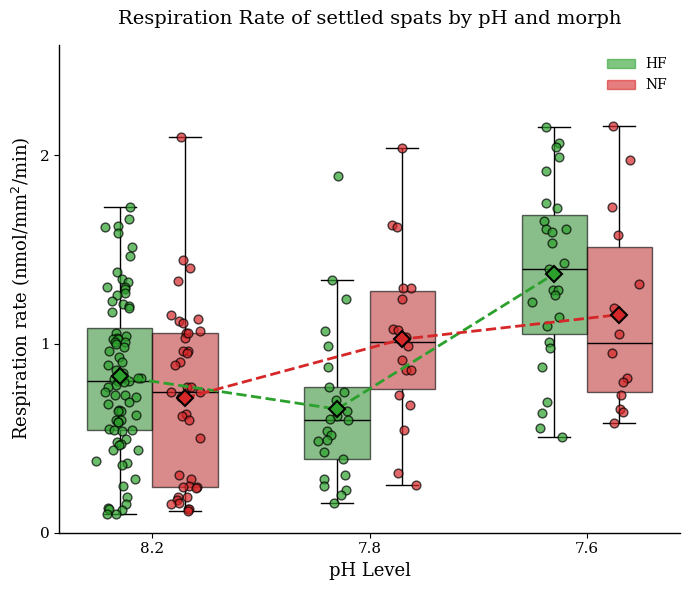

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches # Import for creating legend patches
from statsmodels.stats.multicomp import pairwise_tukeyhsd # Import for Tukey's HSD

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "pH_Spat_Resp.csv"
df = pd.read_csv(filename)

# Normalize / rename the response column once (safer than repeating the long name everywhere)
df = df.rename(columns={"OxyRate nmol/mm2/min": "OxyRate"})

# Keep only HF / NF
target_morphs = ["HF", "NF"]
df = df[df["morph"].isin(target_morphs)].copy()

# --- NEW: Filter samples above 2.09 and print removed samples ---
removed_ph_samples = df[df['OxyRate'] > 2.09]
if not removed_ph_samples.empty:
    print("--- pH Samples Removed (OxyRate > 2.09) ---")
    for index, row in removed_ph_samples.iterrows():
        print(f"Morph: {row['morph']}, OxyRate: {row['OxyRate']:.2f}")
    print("--------------------------------------------")
df = df[df['OxyRate'] <= 2.09]
# ----------------------------------------------------------------

# Ensure pH is clean and ordered (robust to 7.60 vs 7.6)
df["pH"] = df["pH"].astype(str).str.strip()
ph_order = ["8.2", "7.8", "7.6"] # Reversed order
df["pH"] = pd.Categorical(df["pH"], categories=ph_order, ordered=True)

# Optional: drop rows with unexpected pH values (prevents empty categories / odd plotting)
df = df[df["pH"].isin(ph_order)].copy()

# ==========================================
# 2. STATISTICS (Two-Way ANOVA & Tukey's HSD)
# ==========================================
model = ols("OxyRate ~ C(morph) + C(pH) + C(morph):C(pH)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA Results ===")
print(anova_table)

p_morph = anova_table.loc["C(morph)", "PR(>F)"]
p_ph = anova_table.loc["C(pH)", "PR(>F)"]
p_inter = anova_table.loc["C(morph):C(pH)", "PR(>F)"]

def format_pvalue(p):
    return "< 0.0001" if p < 0.0001 else f"= {p:.3f}"

# 2.1 Tukey's HSD Post-hoc Test
# Create a "group" column for interaction comparisons
df['group'] = df['morph'].astype(str) + "_" + df['pH'].astype(str)

# Run Tukey's HSD
tukey_result = pairwise_tukeyhsd(endog=df['OxyRate'], groups=df['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result)

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

# Consistent dodge so layers align
dodge_width = 0.35

fig, ax = plt.subplots(figsize=(7, 6))

# ==========================================
# 4. PLOT CONSTRUCTION (MANUAL ALIGNMENT)
# ==========================================
box_width = 0.6
offset = box_width / 4   # half of half-width → perfect centering

x_positions = {
    "HF": -offset,
    "NF": +offset
}

for morph in morph_order:
    sub = df[df["morph"] == morph]

    # A. Boxplots (no hue)
    sns.boxplot(
        data=sub, x="pH", y="OxyRate",
        order=ph_order,
        width=box_width / 2,
        color=variant_colors[morph],
        showfliers=False, linewidth=1,
        boxprops=dict(edgecolor="black", alpha=0.6),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        ax=ax,
        positions=np.arange(len(ph_order)) + x_positions[morph]
    )

    # B. Jittered points (exact same positions)
    for i, ph in enumerate(ph_order):
        y = sub[sub["pH"] == ph]["OxyRate"]
        x = np.random.normal(i + x_positions[morph], 0.04, size=len(y))
        ax.scatter(
            x, y,
            s=40, c=variant_colors[morph],
            edgecolors="black", linewidths=1,
            alpha=0.7, zorder=3
        )

    # C. Mean diamonds (changed from median)
    means = sub.groupby("pH")["OxyRate"].mean().reindex(ph_order)

    ax.plot(
        np.arange(len(ph_order)) + x_positions[morph],
        means,
        marker="D", linestyle="--",
        markersize=8,
        markerfacecolor=variant_colors[morph],
        markeredgecolor="black",   # ✅ black outline
        markeredgewidth=1.5,
        linewidth=2,
        color=variant_colors[morph],
        zorder=4
    )

# ==========================================
# 5. LABELS, LEGEND & ANNOTATION
# ==========================================
ax.set_ylabel("Respiration rate (nmol/mm$^2$/min)", fontsize=13)
ax.set_xlabel("pH Level", fontsize=13)
ax.set_title("Respiration Rate of settled spats by pH and morph", fontsize=14, pad=15)

# Custom Legend (Top Right) for box plots
legend_handles = []
for morph in morph_order:
    # Create a colored patch resembling a box, with matching alpha
    patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
    legend_handles.append(patch)
ax.legend(handles=legend_handles, labels=morph_order, title=None, frameon=False, loc="upper right")

# Removed the ANOVA text box as requested.

# Y-axis formatting
max_val = df["OxyRate"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

sns.despine(ax=ax)
fig.tight_layout()

# Save options
plt.savefig("Respiration_Rate_by_pH.png", dpi=600)
plt.savefig("Respiration_Rate_by_pH.tiff", dpi=600)
plt.savefig("Respiration_Rate_by_pH_white.svg", dpi=600, facecolor='white')
plt.savefig("Respiration_Rate_by_pH_transparent.svg", dpi=600, transparent=True)
plt.savefig("Respiration_Rate_by_pH.pdf", dpi=600)

plt.show()